# Kitchen Sink Agent — Tutorial Benchmark

Evaluates the **Kitchen Sink** combined agent through the 21-scenario tutorial curriculum.

This agent merges all independently successful components from the Phase 1 screening
into a single architecture, following the Rainbow philosophy (Hessel et al., 2018):

| Component | Source | Mechanism |
|-----------|--------|-----------|
| **Deeper-Residual backbone** | CNN screening | 5-layer CNN with skip connections (RF_R=5) |
| **Spectral Normalisation** | DQN screening | Lipschitz constraint on all Conv3d layers |
| **Munchausen reward** | DQN screening | Implicit KL regularisation via log-policy |
| **NoisyNet heads** | DQN screening | Parametric exploration (no ε-greedy) |

The notebook runs the same protocol as `variant_comparison.ipynb` and `cnn_comparison.ipynb`
for direct comparison with Phase 1 results.

In [2]:
import sys, os, time, random
import numpy as np
import torch

# Ensure project root is on path
_cwd = os.getcwd()
if os.path.basename(_cwd) == "notebooks":
    PROJECT_ROOT = os.path.abspath(os.path.join(_cwd, ".."))
elif os.path.isdir(os.path.join(_cwd, "simulation")):
    PROJECT_ROOT = _cwd
else:
    PROJECT_ROOT = os.path.abspath(os.path.join(_cwd, ".."))

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Project root: /home/franko/CT-DRL-MA
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 2060 SUPER


In [3]:
from simulation.rl.agent_registry import AGENT_REGISTRY, create_agent
from simulation.training.curriculum_trainer import (
    create_env_factory, build_agent_config,
)
from simulation.training.tutorial_runner import TutorialRunner

print(f"Available variants: {list(AGENT_REGISTRY.keys())}")
assert "kitchen_sink" in AGENT_REGISTRY, "Kitchen Sink agent not registered!"

Available variants: ['baseline', 'munchausen', 'spectral_norm', 'noisynet', 'dueling', 'qrdqn', 'iqn', 'kitchen_sink']


In [4]:
# ── Configuration ──────────────────────────────────────────────────────

SEED = 42
MAX_EPOCHS = 500          # max tutorial epochs
MASTERY_THRESHOLD = 0.9   # 90% pass rate over sliding window
WINDOW_SIZE = 20
MIN_EPOCHS = 10
LOG_EVERY = 25            # print progress every N epochs

# Early stopping: abort if not past this tier by this epoch
EARLY_STOP_TIER = 2       # must have mastered tier 2 ("Full chains")
EARLY_STOP_EPOCH = 120    # by epoch 120

print(f"Max epochs: {MAX_EPOCHS}")
print(f"Mastery threshold: {MASTERY_THRESHOLD:.0%}")
print(f"Early stopping: must pass tier {EARLY_STOP_TIER} by epoch {EARLY_STOP_EPOCH}")

Max epochs: 500
Mastery threshold: 90%
Early stopping: must pass tier 2 by epoch 120


In [5]:
# ── Environment factory (shared terminal geometry) ─────────────────────

env_factory = create_env_factory(
    rows=5, bays=58, tiers=5, tracks=7, split_factor=20,
)

# Base agent config (shared yard geometry + training defaults)
base_cfg = build_agent_config(
    rows=5, bays=58, tiers=5, split_factor=20, tracks=7,
)

print(f"Agent config device: {base_cfg.device}")
print(f"Replay buffer: {base_cfg.training.replay_size:,}")
print(f"Batch size: {base_cfg.training.batch_size}")

Agent config device: cuda
Replay buffer: 2,000
Batch size: 32


In [6]:
# ── Create Kitchen Sink agent ─────────────────────────────────────────
#
# The kitchen_sink variant builds its own Deeper-Residual backbone with
# spectral normalisation and NoisyNet heads internally. We just need
# to call create_agent("kitchen_sink", cfg) — no backbone_variant needed.

# Seed everything for reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

agent = create_agent("kitchen_sink", base_cfg)

n_params = sum(p.numel() for p in agent.q_net.parameters())
print(f"Kitchen Sink agent created")
print(f"  Total parameters: {n_params:,}")
print(f"  Backbone type: {type(agent.q_net.backbone).__name__}")
print(f"  Source head type: {type(agent.q_net.source_head).__name__}")
print(f"  Dest head type: {type(agent.q_net.dest_head).__name__}")

# Verify components
param_breakdown = agent.q_net.count_parameters()
for comp, count in param_breakdown.items():
    print(f"  {comp}: {count:,}")

Kitchen Sink agent created
  Total parameters: 181,029
  Backbone type: KitchenSinkCNNBackbone
  Source head type: IdleSourceWrapper
  Dest head type: NoisyDestHead
  backbone: 146,816
  pool: 16,512
  source_head: 3,203
  dest_head: 14,498
  total: 181,029


In [7]:
# ── Run tutorial curriculum ───────────────────────────────────────────

runner = TutorialRunner(
    env_factory=env_factory,
    agent_or_config=agent,
    verbose=True,
)

t0 = time.time()
summary = runner.train_all(
    epochs=MAX_EPOCHS,
    mastery_threshold=MASTERY_THRESHOLD,
    window_size=WINDOW_SIZE,
    min_epochs=MIN_EPOCHS,
    log_every=LOG_EVERY,
    early_stop_check=lambda ep, tier: ep >= EARLY_STOP_EPOCH and tier < EARLY_STOP_TIER,
)
wall_time = time.time() - t0

early_stopped = summary.get("early_stopped", False)
if summary["mastered"]:
    status = "MASTERED"
elif early_stopped:
    status = "EARLY STOPPED"
else:
    status = "NOT MASTERED"

print(f"\n{'='*70}")
print(f"  Result: {status} in {summary['epochs_completed']} epochs")
print(f"  Wall time: {wall_time:.0f}s ({wall_time/60:.1f} min)")
print(f"  Tier reached: {summary['current_tier']}/{summary['n_tiers']}")
avg_rate = np.mean(list(summary['pass_rates'].values()))
print(f"  Average pass rate: {avg_rate:.1%}")
print(f"{'='*70}")


  Tutorial tiers (13 total):
    Tier 0: Primitives [S1, S2, S3, S4]
    Tier 1: Two-action chains [S5, S6, S26, S27]
    Tier 2: Full chains [S7, S8]
    Tier 3: Restack + load [S9, S10]
    Tier 4: Random generalize [S11, S12]
    Tier 5: Multi-step hard [S13, S14]
    Tier 6: Terminal truck [S25, S22, S23, S24]
    Tier 7: Multi-vehicle [S15, S16]
    Tier 8: Bidirectional train [S17]
    Tier 9: Concurrent ops [S18, S19]
    Tier 10: Full complexity [S20, S21]
    Tier 11: Full train ops [S28, S29]
    Tier 12: Cross-modal orchestration [S30, S31]



/home/franko/.cache/pypoetry/virtualenvs/ct-drl-ma-7RJlkqYG-py3.12/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator KernelDensity from version 1.5.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(



  Epoch 25/500 — Tier 0: Primitives
    ► Tier 0: Primitives
      [====================] 100.0% OK S1: park_truck
      [====================] 100.0% OK S2: train_import
      [--------------------]  0.0%    S3: yard_to_truck
      [==================--] 90.0% OK S4: yard_to_train
    🔒 Tier 1: Two-action chains
    🔒 Tier 2: Full chains
    🔒 Tier 3: Restack + load
    🔒 Tier 4: Random generalize
    🔒 Tier 5: Multi-step hard
    🔒 Tier 6: Terminal truck
    🔒 Tier 7: Multi-vehicle
    🔒 Tier 8: Bidirectional train
    🔒 Tier 9: Concurrent ops
    🔒 Tier 10: Full complexity
    🔒 Tier 11: Full train ops
    🔒 Tier 12: Cross-modal orchestration
    Average (active): 72.5% | Mastered: 3/31 | Graduated: 0 | ε=0.645

  Epoch 50/500 — Tier 0: Primitives
    ► Tier 0: Primitives
      [====================] 100.0% OK S1: park_truck
      [====================] 100.0% OK S2: train_import
      [=================---] 85.0%    S3: yard_to_truck
      [====================] 100.0% OK S4: yard

In [8]:
# ── Per-scenario pass rates ──────────────────────────────────────────

import pandas as pd

rows = []
for sid in sorted(summary["pass_rates"].keys()):
    rows.append({
        "Scenario": f"S{sid}: {summary['scenario_names'][sid]}",
        "Pass Rate": f"{summary['pass_rates'][sid]:.1%}",
    })

df_scenarios = pd.DataFrame(rows)
df_scenarios

,Scenario,Pass Rate
0,S1: park_truck,100.0%
1,S2: train_import,100.0%
2,S3: yard_to_truck,90.0%
3,S4: yard_to_train,100.0%
4,S5: import_and_export,100.0%
5,S6: park_then_import,100.0%
6,S7: full_chain_truck,100.0%
7,S8: delivery_to_train,100.0%
8,S9: unbury_for_truck,100.0%
9,S10: unbury_for_train,100.0%


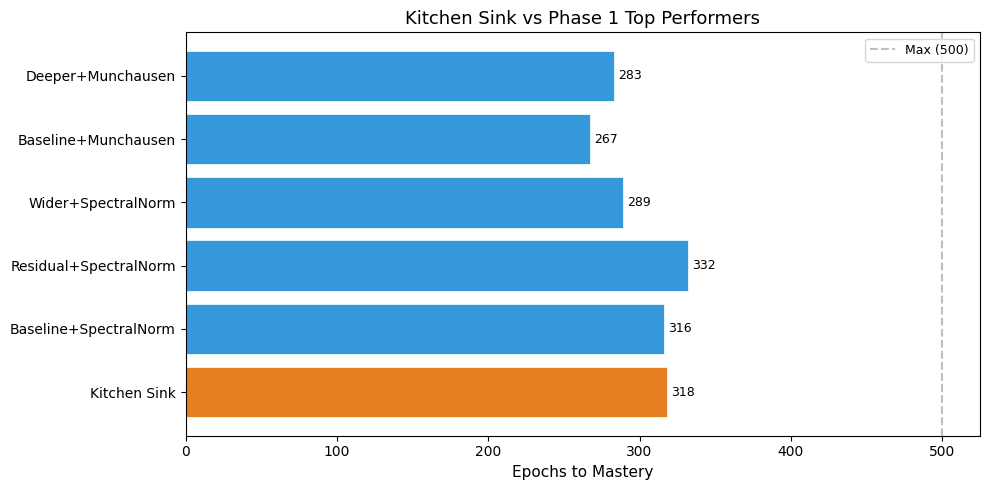

Saved: kitchen_sink_comparison.png


In [9]:
# ── Comparison with Phase 1 results ──────────────────────────────────
# Load previous results if available for side-by-side comparison

import json
import matplotlib.pyplot as plt
import matplotlib

# Kitchen sink result
ks_result = {
    "epochs": summary["epochs_completed"],
    "mastered": summary["mastered"],
    "current_tier": summary["current_tier"],
    "n_tiers": summary["n_tiers"],
    "pass_rates": summary["pass_rates"],
    "scenario_names": summary["scenario_names"],
    "wall_time_s": wall_time,
    "n_params": n_params,
}

# Reference results from Phase 1 top performers (epochs to mastery)
reference = {
    "Deeper+Munchausen": {"epochs": 283, "avg_rate": 0.995},
    "Baseline+Munchausen": {"epochs": 267, "avg_rate": 0.974},
    "Wider+SpectralNorm": {"epochs": 289, "avg_rate": 0.950},
    "Residual+SpectralNorm": {"epochs": 332, "avg_rate": 0.929},
    "Baseline+SpectralNorm": {"epochs": 316, "avg_rate": 0.910},
}

fig, ax = plt.subplots(figsize=(10, 5))

# Add kitchen sink
names = list(reference.keys()) + ["Kitchen Sink"]
epochs = [r["epochs"] for r in reference.values()] + [ks_result["epochs"]]
colors = ["#3498db"] * len(reference) + ["#e67e22"]

bars = ax.barh(names, epochs, color=colors, edgecolor="white", linewidth=0.5)

for bar, ep in zip(bars, epochs):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2,
            f"{ep}", va="center", fontsize=9)

ax.set_xlabel("Epochs to Mastery", fontsize=11)
ax.set_title("Kitchen Sink vs Phase 1 Top Performers", fontsize=13)
ax.axvline(x=MAX_EPOCHS, color="gray", linestyle="--", alpha=0.5, label=f"Max ({MAX_EPOCHS})")
ax.legend(fontsize=9)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("kitchen_sink_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: kitchen_sink_comparison.png")

In [10]:
# ── Save results to JSON ─────────────────────────────────────────────

serializable = {
    **ks_result,
    "pass_rates": {str(k): v for k, v in ks_result["pass_rates"].items()},
    "scenario_names": {str(k): v for k, v in ks_result["scenario_names"].items()},
}

with open("kitchen_sink_results.json", "w") as f:
    json.dump(serializable, f, indent=2)

print("Saved: kitchen_sink_results.json")
print("\nDone! The Kitchen Sink agent tutorial evaluation is complete.")

Saved: kitchen_sink_results.json

Done! The Kitchen Sink agent tutorial evaluation is complete.


In [10]:
# ── GPU cleanup ──────────────────────────────────────────────────────
import gc

agent.q_net.cpu()
agent.target_net.cpu()
agent.replay = None
del agent, runner
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    allocated = torch.cuda.memory_allocated() / 1024**2
    reserved = torch.cuda.memory_reserved() / 1024**2
    print(f"GPU cleanup: {allocated:.0f} MB allocated, {reserved:.0f} MB reserved")

GPU cleanup: 17 MB allocated, 362 MB reserved
